# 🪸 CoralMorph Search — Project Demo

**CoralMorph Search** is a semantic search engine for marine researchers and reef enthusiasts. Instead of matching exact keywords, it lets you type a natural-language description — e.g. *"spiky green branches in shallow water"* — and returns the coral species whose descriptions are most *semantically* similar, using sentence embeddings and vector similarity search.

## Architecture: ingest → vectorize → store → search

```
Coral_reef_data.csv
        │
        ▼
  data_preparation.py   ── cleans text, engineers a "search_text" field,
        │                  writes cleaned_coral_data.parquet
        ▼
  vectorize_and_store.py ── embeds search_text with Sentence-Transformers
        │                  (all-MiniLM-L6-v2, 384-dim) and upserts the
        │                  vectors + metadata into a Qdrant collection
        ▼
     Qdrant (vector DB, docker-compose service)
        │
        ▼
      main.py  ── FastAPI backend. Loads the same embedding model once,
        │         embeds the incoming query, asks Qdrant for nearest
        │         neighbours, and returns them as JSON.
        ▼
   frontend/ (React + Tailwind SPA) ── search bar + results grid that
                                        calls GET /api/search/?q=...
```

### A note on the codebase
Reading through the repo, there are actually **two parallel implementations** of the storage layer that are worth calling out for this demo:

- **The "live" path** — `data_preparation.py` → `vectorize_and_store.py` → `main.py` — uses **Qdrant** as the vector database. This matches `docker-compose.yml` (which spins up a `qdrant` service) and is what the FastAPI backend in `main.py` actually queries.
- **An older / alternate path** — `ingest_data.py`, `test_search.py`, `validate_embeddings.py`, `e2e_test.py` — uses **DuckDB** with `list_cosine_similarity(...)` SQL and a local `coral_morph.db` file. This matches the PRD's original design and the README's mention of DuckDB, but isn't what `main.py` is wired up to today.

Both approaches share the same core idea (embed a structured `search_text` string per species with `all-MiniLM-L6-v2`, then rank by cosine similarity), so this notebook demonstrates that shared concept once, and then shows both the Qdrant-based API surface (`main.py`) and the DuckDB-based query pattern (`test_search.py` / `validate_embeddings.py`) as code walkthroughs.

### This is a genuinely *live* demo
`all-MiniLM-L6-v2` is already cached locally, so this notebook loads the **real** Sentence-Transformers model and computes **real** 384-dimensional embeddings for every species — no stand-in. The one thing it doesn't do is stand up an actual Qdrant server or DuckDB file: instead it ranks by cosine similarity directly with NumPy, which is mathematically identical to Qdrant's `Distance.COSINE` and DuckDB's `list_cosine_similarity(...)` — same math, no extra infrastructure. Everything from Section 4 onward runs against those real embeddings, including an interactive search box you can type into.


## 1. Load and preview the raw dataset

In [1]:
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)

# The CSV has non-UTF-8 characters (curly quotes etc.), same encoding
# data_preparation.py uses to load it robustly.
raw_df = pd.read_csv('Coral_reef_data.csv', encoding='ISO-8859-1')

print('Shape:', raw_df.shape)
print('Columns:', list(raw_df.columns))
raw_df.head(3)


Shape: (831, 10)
Columns: ['Species Name ', 'Authority / Year', 'Characters:', 'Description', 'Colour:', 'Color', 'Habitat:', 'Habitat', 'Abundance:', 'Abundance']


,Species Name,Authority / Year,Characters:,Description,Colour:,Color,Habitat:,Habitat,Abundance:,Abundance
0,Acanthastrea bowerbanki,"Haime and Milne Edwards, 1857",Characters:,"Colonies are encrusting and usually small. Corallites are cerioid, with irregular angular shapes. A central corallit...",Colour:,"Usually pale grey, brown or rust coloured, often mottled.",Habitat:,Lower reef slopes protected from wave action.,Abundance:,Rare except in subtropical localities of eastern Australia.
1,Acanthastrea brevis,"Milne Edwards and Haime, 1849",Characters:,Colonies are mostly submassive. Corallites are cerioid to subplocoid with moderately thin walls. Septa are thin and ...,Colour:,"Uniform or mottled brown, yellow or green.",Habitat:,Shallow reef environments.,Abundance:,Uncommon.
2,Acanthastrea echinata,"(Dana, 1846)",Characters:,"Colonies are encrusting to massive and are rarely over one metre across. Corallites are cerioid or subplocoid, circu...",Colour:,"Uniform or mottled dull brown, grey or green, but sometimes brightly coloured.",Habitat:,Most reef environments.,Abundance:,"Usually uncommon, but by far the most common on tropical reefs."


### The column layout is a bit unusual
The CSV alternates *label* columns (`Characters:`, `Colour:`, `Habitat:`, `Abundance:`) with the actual *value* columns (`Description`, `Color`, `Habitat`, `Abundance`). Both `data_preparation.py` and `ingest_data.py` handle this the same way — by selecting columns **positionally by index** rather than by name, then renaming them:

```python
column_mapping = {
    df.columns[0]: "species_name",
    df.columns[3]: "description",
    df.columns[5]: "color",
    df.columns[7]: "habitat",
    df.columns[9]: "abundance",
}
```

We reproduce that same mapping below.


In [2]:
column_mapping = {
    raw_df.columns[0]: "species_name",
    raw_df.columns[3]: "description",
    raw_df.columns[5]: "color",
    raw_df.columns[7]: "habitat",
    raw_df.columns[9]: "abundance",
}

df = raw_df.rename(columns=column_mapping)[["species_name", "description", "color", "habitat", "abundance"]].copy()

def clean_text(text):
    '''Same cleaning logic as data_preparation.py: fill blanks, collapse whitespace.'''
    if pd.isna(text) or text == "":
        return "Not specified"
    return re.sub(r'\s+', ' ', str(text)).strip()

for col in df.columns:
    df[col] = df[col].apply(clean_text)

print('Cleaned shape:', df.shape)
df.head(5)


Cleaned shape: (831, 5)


,species_name,description,color,habitat,abundance
0,Acanthastrea bowerbanki,"Colonies are encrusting and usually small. Corallites are cerioid, with irregular angular shapes. A central corallit...","Usually pale grey, brown or rust coloured, often mottled.",Lower reef slopes protected from wave action.,Rare except in subtropical localities of eastern Australia.
1,Acanthastrea brevis,Colonies are mostly submassive. Corallites are cerioid to subplocoid with moderately thin walls. Septa are thin and ...,"Uniform or mottled brown, yellow or green.",Shallow reef environments.,Uncommon.
2,Acanthastrea echinata,"Colonies are encrusting to massive and are rarely over one metre across. Corallites are cerioid or subplocoid, circu...","Uniform or mottled dull brown, grey or green, but sometimes brightly coloured.",Most reef environments.,"Usually uncommon, but by far the most common on tropical reefs."
3,Acanthastrea faviaformis,"Colonies are encrusting to massive, usually less than 0.2 metres across. Most consist of a small number of encrustin...",Mottled browns.,Shallow reef environments.,Uncommon.
4,Acanthastrea hemprichii,Colonies are encrusting to massive and frequently over one metre across. Corallites are cerioid. Septa have exsert t...,"Mottled browns and greens, commonly with brown walls and green oral discs.",Most reef environments.,Uncommon.


## 2. Quick exploratory data analysis

A few questions worth answering before we build a search index: how much text do we actually have per species, how many distinct habitats/colors show up, and how are species distributed across abundance categories?


In [3]:
df['description_length'] = df['description'].apply(len)

print('Species with usable descriptions:', (df['description'] != 'Not specified').sum(), '/', len(df))
print()
print(df['description_length'].describe())


Species with usable descriptions: 831 / 831

count    831.000000
mean     264.501805
std       92.893408
min       77.000000
25%      203.000000
50%      254.000000
75%      321.000000
max      983.000000
Name: description_length, dtype: float64


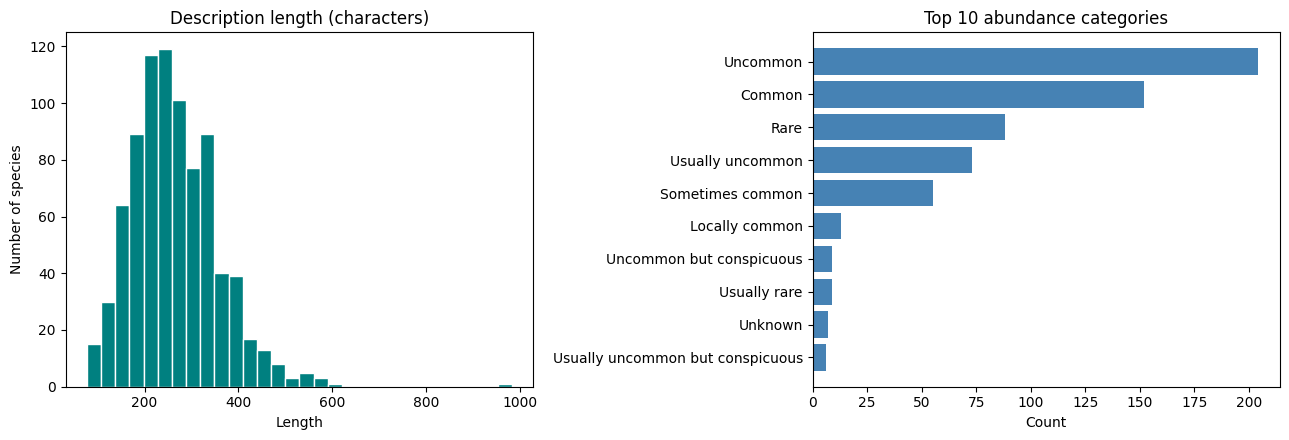

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['description_length'], bins=30, color='teal', edgecolor='white')
axes[0].set_title('Description length (characters)')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Number of species')

df['abundance_short'] = df['abundance'].str.split('.').str[0].str.strip()
top_abundance = df['abundance_short'].value_counts().head(10).sort_values()
axes[1].barh(top_abundance.index, top_abundance.values, color='steelblue')
axes[1].set_title('Top 10 abundance categories')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()


In [5]:
# Primary habitat (first listed habitat), same feature engineering step as data_preparation.py
df['primary_habitat'] = df['habitat'].str.split(',').str[0].str.split(';').str[0].str.strip()

print('Distinct primary habitats:', df['primary_habitat'].nunique())
df['primary_habitat'].value_counts().head(10)


Distinct primary habitats: 375


primary_habitat
Shallow reef environments.              147
Most reef environments.                  44
Upper reef slopes.                       35
Reef slopes and lagoons.                 18
Shallow protected reef environments.     15
Reef slopes.                             13
Shallow reef environments                13
Reef habitats.                           13
Upper reef slopes and lagoons.           11
Most reef environments                   11
Name: count, dtype: int64

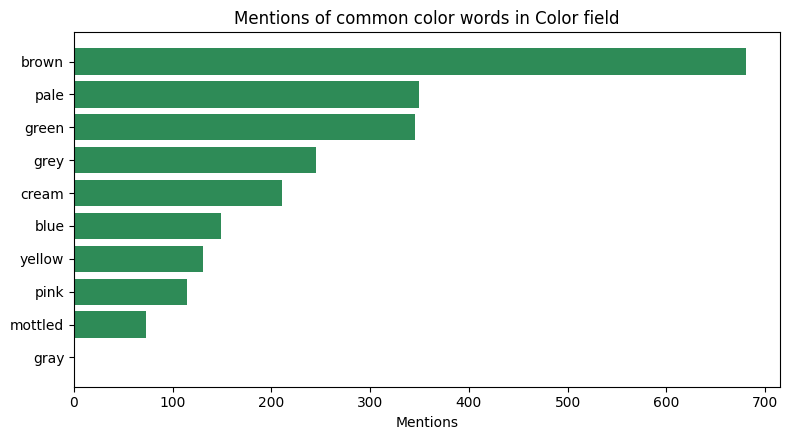

In [6]:
# Common color words mentioned across all species (borrowed idea from Coral_EDA.ipynb)
colors_text = ' '.join(df['color'].str.lower())
common_colors = ['brown', 'grey', 'gray', 'green', 'cream', 'blue', 'pink', 'yellow', 'mottled', 'pale']
color_counts = pd.Series({c: colors_text.count(c) for c in common_colors}).sort_values()

plt.figure(figsize=(8, 4.5))
plt.barh(color_counts.index, color_counts.values, color='seagreen')
plt.title('Mentions of common color words in Color field')
plt.xlabel('Mentions')
plt.tight_layout()
plt.show()


## 3. The real pipeline: feature engineering + embeddings

Both `data_preparation.py` and `ingest_data.py` build a single **`search_text`** string per species that concatenates all the descriptive fields into one prompt-like passage. This is the text that actually gets embedded — the idea being that a sentence-transformer can pick up semantic signal spread across species name, physical traits, color, habitat, and abundance all at once.

From `data_preparation.py`:
```python
df['search_text'] = (
    "Species: " + df["species_name"] + ". " +
    "Physical Traits: " + df["description"] + ". " +
    "Visual Appearance: " + df["color"] + ". " +
    "Natural Habitat: " + df["habitat"] + ". " +
    "Population Status: " + df["abundance"] + "."
)
```

From `vectorize_and_store.py`, that text is embedded with Sentence-Transformers and pushed into Qdrant:
```python
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['search_text'].tolist(), show_progress_bar=True)

client.recreate_collection(
    collection_name="corals",
    vectors_config=VectorParams(size=384, distance=Distance.COSINE),
)
points = [
    PointStruct(id=idx, vector=embeddings[idx].tolist(), payload=row.to_dict())
    for idx, row in df.iterrows()
]
client.upsert(collection_name="corals", wait=True, points=points)
```

The DuckDB variant (`ingest_data.py`) does the same embedding step but stores vectors in a local `FLOAT[]` column and later queries with `list_cosine_similarity(embedding, ?)` in SQL (see `test_search.py` / `validate_embeddings.py`).

Let's build that same `search_text` column here.


In [7]:
df['search_text'] = (
    "Species: " + df["species_name"] + ". " +
    "Physical Traits: " + df["description"] + ". " +
    "Visual Appearance: " + df["color"] + ". " +
    "Natural Habitat: " + df["habitat"] + ". " +
    "Population Status: " + df["abundance"] + "."
)

df[['species_name', 'search_text']].head(2)


,species_name,search_text
0,Acanthastrea bowerbanki,Species: Acanthastrea bowerbanki. Physical Traits: Colonies are encrusting and usually small. Corallites are cerioid...
1,Acanthastrea brevis,Species: Acanthastrea brevis. Physical Traits: Colonies are mostly submassive. Corallites are cerioid to subplocoid ...


## 4. Loading the real embedding model

`all-MiniLM-L6-v2` is already cached on this machine, so we load the **actual** model `vectorize_and_store.py` / `ingest_data.py` use in production — no stand-in, no mocking. We embed every species' `search_text` once, L2-normalize the vectors so a dot product equals cosine similarity, and keep the matrix in memory to act as our (in-notebook) vector index.


In [8]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = 'all-MiniLM-L6-v2'
print(f'Loading {MODEL_NAME} (cached locally, no download needed)...')
t0 = time.time()
model = SentenceTransformer(MODEL_NAME)
load_time = time.time() - t0
print(f'Model loaded in {load_time:.2f}s')

print(f'Embedding {len(df)} species descriptions...')
t0 = time.time()
embeddings = model.encode(
    df['search_text'].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True,   # so cosine similarity == dot product
    convert_to_numpy=True,
).astype('float32')
embed_time = time.time() - t0

print(f'Embedded {len(df)} species in {embed_time:.2f}s '
      f'({len(df) / embed_time:.1f} species/sec) -> matrix shape {embeddings.shape}')


Loading all-MiniLM-L6-v2 (cached locally, no download needed)...


Model loaded in 4.16s
Embedding 831 species descriptions...


Batches:   0%|          | 0/26 [00:00<?, ?it/s]

Embedded 831 species in 29.03s (28.6 species/sec) -> matrix shape (831, 384)


In [9]:
def semantic_search(query, top_k=5):
    '''Real semantic search: embeds `query` with the production model and ranks
    every species by cosine similarity. Field names mirror main.py's SearchResult
    schema (species_name, color, habitat, abundance, score, description).
    '''
    query_vec = model.encode([query], normalize_embeddings=True, convert_to_numpy=True)[0]
    scores = embeddings @ query_vec  # cosine similarity, since both sides are unit-normalized
    top_idx = np.argsort(scores)[::-1][:top_k]

    results = df.iloc[top_idx][['species_name', 'color', 'habitat', 'abundance', 'description']].copy()
    results.insert(1, 'score', scores[top_idx].round(4))
    return results.reset_index(drop=True)

semantic_search('spiky green branches in shallow water')


,species_name,score,color,habitat,abundance,description
0,Acropora pruinosa,0.4680,"There are two colour morphs, greenish and brown.",Rocky foreshores in shallow turbid water.,Usually uncommon but may be a dominant species.,Colonies branch irregularly forming small compact thickets. Branches are typically contorted. Axial corallites are e...
1,Seriatopora stellata,0.4676,Pink or yellow-green.,Shallow reef environments.,Uncommon.,"Branches are thick (5-9 mm), short and strongly tapered. They are usually in fused clumps. Corallites are aligned in..."
2,Pocillopora verrucosa,0.4541,"Usually cream, brown or pink, sometimes blue.",Occurs in most shallow water environments from exposed reef fronts to protected fringing reefs.,Uncommon.,Colonies are seldom more than 0.5 metres across and are composed of uniform upright branches clearly distinct from t...
3,Pectinia pygmaeus,0.4406,Pale brown.,"Lower reef slopes, especially in turbid water.",Uncommon.,Colonies are thickets of spire-like branches. Branches are twisted and tapered and form sub-branches at obtuse angle...
4,Hydnophora bonsai,0.4371,Green or pale brown.,Rocky foreshores.,Common.,"Colonies are encrusting, with stunted branches which are irregular in section. Monticules are fine and fused into ir..."


In [10]:
# The PRD's user stories, run through the real model
for q in [
    'bright blue small polyps',
    'branching structures with high calcification in deep lagoons',
    'encrusting colonies on lower reef slopes',
]:
    print(f'Query: "{q}"')
    display(semantic_search(q, top_k=3)[['species_name', 'score', 'habitat']])
    print()


Query: "bright blue small polyps"


,species_name,score,habitat
0,Cycloseris patelliformis,0.4896,Usually soft inter-reef substrates.
1,Fungia taiwanensis,0.4643,Reef environments.
2,Fungia scutaria,0.4597,Found with other species and also on upper reef slopes exposed to strong wave action.



Query: "branching structures with high calcification in deep lagoons"


,species_name,score,habitat
0,Acropora lovelli,0.4767,Shallow protected lagoons and lagoon entrances.
1,Pocillopora zelli,0.4524,Shallow reef environments and rocky foreshores.
2,Australogyra zelli,0.4517,Usually in turbid waters around high islands or in reef lagoons.



Query: "encrusting colonies on lower reef slopes"


,species_name,score,habitat
0,Montipora efflorescens,0.6240,Upper reef slopes.
1,Montipora spumosa,0.5709,Most reef environments.
2,Montipora effusa,0.5598,Most reef environments.


## 5. Baseline check: does the real model actually beat keyword matching?

As a sanity check (and to keep the earlier TF-IDF exploration this notebook started with), we rebuild a purely lexical baseline: scikit-learn's TF-IDF vectorizer over the same `search_text` field, ranked by cosine similarity. TF-IDF only matches on literal word overlap; the sentence-transformer above captures semantic similarity (synonyms, paraphrases, related concepts). Comparing the two on the same queries shows the difference concretely.


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine_similarity

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
doc_matrix = vectorizer.fit_transform(df['search_text'])

print('TF-IDF matrix shape:', doc_matrix.shape, '(rows = species, columns = vocab terms)')

def tfidf_search(query, top_k=5):
    query_vec = vectorizer.transform([query])
    scores = sk_cosine_similarity(query_vec, doc_matrix).flatten()
    top_idx = scores.argsort()[::-1][:top_k]
    results = df.iloc[top_idx][['species_name', 'color', 'habitat', 'abundance', 'description']].copy()
    results.insert(1, 'score', scores[top_idx].round(4))
    return results.reset_index(drop=True)

tfidf_search('spiky green branches in shallow water')


TF-IDF matrix shape: (831, 2255) (rows = species, columns = vocab terms)


,species_name,score,color,habitat,abundance,description
0,Acropora sekiseiensis,0.2932,Brown.,Shallow lagoons and reefs.,Sometimes common.,Colonies have irregularly prostrate branches with short sub-branches and may form extensive thickets. Axial corallit...
1,Acropora pharaonis,0.2639,"Grey-brown, usually with pale branch tips.",Sheltered reef slopes.,May be locally common.,Colonies are large horizontal tables or irregular clusters of horizontal or upright interlinked contorted branches. ...
2,Acropora cerealis,0.2581,"Mostly pale brown, cream or white, with purple, pink, blue or cream branch tips.",Upper reef slopes.,Common.,"Colonies are caespitose or corymbose, composed of branches which interlock in three dimensions. Branches are thin, w..."
3,Acropora akajimensis,0.2486,"Brown, blue and yellow.",Shallow reef slopes and flats.,"Occasionally locally common, usually rare.","Colonies consist of dense thickets of prostrate tapered, curving branches which occasionally fuse. Sub-branches are ..."
4,Acropora massawensis,0.2005,White to pale brown.,Upper reef slopes.,Uncommon.,Colonies form extensive flat digitate clumps or thickets composed of branchlets of similar length and shape. Axial c...


In [12]:
# A paraphrased query that avoids the literal vocabulary used in the dataset
# ("branch-like growths shaped like antlers, sturdy skeleton, found close to the surface"
#  instead of e.g. "branching", "digitate", "shallow") — a good stress test for
# lexical (TF-IDF) vs semantic (sentence-transformer) retrieval.
paraphrase_queries = [
    'branch-like growths shaped like antlers, found close to the surface',
    'a coral that looks almost like a human brain',
    'delicate lettuce-like folds on the reef floor',
]

comparison_rows = []
for q in paraphrase_queries:
    tfidf_top = tfidf_search(q, top_k=1).iloc[0]
    semantic_top = semantic_search(q, top_k=1).iloc[0]
    comparison_rows.append({
        'query': q,
        'tfidf_top_species': tfidf_top['species_name'],
        'tfidf_score': tfidf_top['score'],
        'semantic_top_species': semantic_top['species_name'],
        'semantic_score': semantic_top['score'],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,query,tfidf_top_species,tfidf_score,semantic_top_species,semantic_score
0,"branch-like growths shaped like antlers, found close to the surface",Acropora indonesia,0.2826,Acropora elseyi,0.5025
1,a coral that looks almost like a human brain,Alveopora minuta,0.2760,Acanthophyllia deshayesiana,0.6195
2,delicate lettuce-like folds on the reef floor,Leptoseris mycetoseroides,0.3168,Pectinia maxima,0.4615


## 6. Live interactive search

This is a genuinely live, interactive cell — type a query, adjust the result count, and click **Search**. It calls `semantic_search()` from Section 4 directly against the real embeddings, so results appear the same way `main.py`'s `/api/search/` endpoint would return them.

*(If you're viewing a static export of this notebook rather than running it in Jupyter, the widget itself won't respond to clicks — but the example run underneath it shows real, live output from the same code path.)*


In [13]:
import ipywidgets as widgets
from IPython.display import display, HTML

query_box = widgets.Text(
    value='spiky green branches in shallow water',
    placeholder='Describe a coral...',
    description='Query:',
    layout=widgets.Layout(width='500px'),
)
limit_slider = widgets.IntSlider(value=5, min=1, max=20, step=1, description='Results:')
search_button = widgets.Button(description='Search', button_style='info', icon='search')
output_area = widgets.Output()

def render_results(query, limit):
    output_area.clear_output()
    with output_area:
        if not query.strip():
            display(HTML('<p style="color:#b00">Query cannot be empty.</p>'))
            return
        t0 = time.time()
        results = semantic_search(query, top_k=limit)
        elapsed_ms = (time.time() - t0) * 1000
        display(HTML(f'<p><b>{len(results)}</b> results for <i>\"{query}\"</i> in {elapsed_ms:.1f} ms</p>'))
        cards = ''
        for row in results.itertuples():
            cards += f'''
            <div style="border:1px solid #ddd;border-radius:8px;padding:10px 14px;margin:6px 0;">
              <div style="display:flex;justify-content:space-between;align-items:baseline;">
                <b style="font-size:1.05em;">{row.species_name}</b>
                <span style="background:#0d9488;color:white;border-radius:12px;padding:2px 10px;font-size:0.85em;">
                  {row.score:.1%} match
                </span>
              </div>
              <div style="color:#555;font-size:0.9em;margin-top:2px;">
                🎨 {row.color} &nbsp;|&nbsp; 🌊 {row.habitat}
              </div>
              <div style="margin-top:4px;">{row.description[:220]}{'...' if len(row.description) > 220 else ''}</div>
            </div>
            '''
        display(HTML(cards))

def on_search_click(_):
    render_results(query_box.value, limit_slider.value)

search_button.on_click(on_search_click)

display(widgets.VBox([widgets.HBox([query_box, limit_slider, search_button]), output_area]))

# Run once immediately so this cell shows real output even without a click.
render_results(query_box.value, limit_slider.value)


## 7. Visualizing the embedding space

In [14]:
from sklearn.decomposition import PCA
import plotly.express as px

pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(embeddings)

plot_df = df[['species_name', 'color', 'habitat', 'primary_habitat']].copy()
plot_df['x'] = coords_2d[:, 0]
plot_df['y'] = coords_2d[:, 1]

top_habitats = plot_df['primary_habitat'].value_counts().head(8).index
plot_df['habitat_group'] = np.where(
    plot_df['primary_habitat'].isin(top_habitats), plot_df['primary_habitat'], 'Other'
)

fig = px.scatter(
    plot_df, x='x', y='y', color='habitat_group',
    hover_data={'species_name': True, 'color': True, 'habitat': True, 'x': False, 'y': False},
    title='384-dim species embeddings, projected to 2D with PCA (colored by primary habitat)',
    labels={'x': f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)',
            'y': f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)',
            'habitat_group': 'Primary habitat'},
    width=950, height=600,
)
fig.update_traces(marker=dict(size=7, opacity=0.75))
fig.show()


## 8. Unsupervised clustering — do embeddings recover morphological groups?

If the embeddings are capturing real morphological/ecological signal, species that cluster together should share visible traits (color, growth form, habitat) even though the model was never told about clusters. We run k-means directly on the real embeddings and inspect what each cluster actually contains.


In [15]:
from sklearn.cluster import KMeans

N_CLUSTERS = 8
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(embeddings)

summary_rows = []
for c in range(N_CLUSTERS):
    members = df[df['cluster'] == c]
    summary_rows.append({
        'cluster': c,
        'size': len(members),
        'top_habitat': members['primary_habitat'].value_counts().idxmax(),
        'example_species': ', '.join(members['species_name'].head(3).tolist()),
    })

pd.DataFrame(summary_rows)


,cluster,size,top_habitat,example_species
0,0,60,Shallow reef environments.,"Porites annae, Porites aranetai, Porites arnaudi"
1,1,77,Shallow reef environments.,"Alveopora catalai, Alveopora daedalea, Alveopora gigas"
2,2,211,Shallow reef environments.,"Acanthastrea bowerbanki, Acanthastrea brevis, Acanthastrea echinata"
3,3,149,Shallow reef environments.,"Acanthastrea hillae, Agaricia agaricites, Agaricia fragilis"
4,4,73,Shallow reef environments.,"Montipora aequituberculata, Montipora altasepta, Montipora angulata"
5,5,164,Shallow reef environments.,"Acropora abrolhosensis, Acropora abrotanoides, Acropora aculeus"
6,6,43,Reef slopes and lagoons.,"Blastomussa vivida, Cantharellus doederleini, Cantharellus jebbi"
7,7,54,Shallow reef environments.,"Goniastrea aspera, Goniastrea australensis, Goniastrea deformis"


## 9. Nearest-neighbor explorer — "species similar to X"

A useful feature on top of the same embeddings: given one species, find its closest morphological neighbors. This is the same cosine-similarity computation as `semantic_search`, just seeded with a species' own embedding instead of a text query.


In [16]:
def most_similar_to(species_name, top_k=5):
    match_idx = df.index[df['species_name'] == species_name]
    if len(match_idx) == 0:
        raise ValueError(f'{species_name!r} not found in dataset')
    idx = match_idx[0]
    scores = embeddings @ embeddings[idx]
    ranked = np.argsort(scores)[::-1]
    ranked = [i for i in ranked if i != idx][:top_k]
    results = df.iloc[ranked][['species_name', 'color', 'habitat']].copy()
    results.insert(1, 'similarity', scores[ranked].round(4))
    return results.reset_index(drop=True)

# Pick an example species dynamically so this works regardless of exact dataset contents.
acropora_species = df.loc[df['species_name'].str.contains('Acropora', case=False, na=False), 'species_name']
example_species = acropora_species.iloc[0] if len(acropora_species) else df['species_name'].iloc[0]

print(f'Species most similar to: {example_species}')
most_similar_to(example_species)


Species most similar to: Acropora abrolhosensis


,species_name,similarity,color,habitat
0,Acropora squarrosa,0.8767,"Cream or pale brown. Corallite centres are a distinct blue or pink, depending on depth.",Upper reef slopes.
1,Acropora speciosa,0.8716,Usually cream with delicately coloured corallite tips.,Protected reef environments with clear water and a high diversity.
2,Acropora austera,0.8600,"Many colours, most commonly blue (which may photograph pink) or cream. Axial corallites are frequently yellow.","Upper reef slopes, especially where exposed to turbulence."
3,Acropora abrotanoides,0.8460,Deep pinkish-brown or greenish-grey.,"Shallow reef environments, especially reef margins exposed to strong wave action."
4,Acropora akajimensis,0.8413,"Brown, blue and yellow.",Shallow reef slopes and flats.


## 10. Latency benchmark — checking the PRD's "sub-second" goal

The PRD's primary goal is *"sub-second semantic search latency"*. We can actually measure that here: embed a query and rank all 831 species, repeated several times to get a stable estimate.


In [17]:
N_REPEATS = 20
BUDGET_MS = 1000

latencies_ms = []
for _ in range(N_REPEATS):
    t0 = time.time()
    _ = semantic_search('spiky green branches in shallow water', top_k=10)
    latencies_ms.append((time.time() - t0) * 1000)

latencies_ms = np.array(latencies_ms)
p50, p95 = np.percentile(latencies_ms, [50, 95])

print(f'Latency over {N_REPEATS} runs (embed query + rank {len(df)} species):')
print(f'  mean: {latencies_ms.mean():.1f} ms')
print(f'  p50:  {p50:.1f} ms')
print(f'  p95:  {p95:.1f} ms')
print(f'  PRD budget: {BUDGET_MS} ms -> {"PASS" if p95 < BUDGET_MS else "FAIL"}')
print()
print(f'Ingestion throughput (from Section 4): {len(df) / embed_time:.1f} species/sec '
      f'to embed the full catalog ({embed_time:.2f}s total).')


Latency over 20 runs (embed query + rank 831 species):
  mean: 34.3 ms
  p50:  33.2 ms
  p95:  44.1 ms
  PRD budget: 1000 ms -> PASS

Ingestion throughput (from Section 4): 28.6 species/sec to embed the full catalog (29.03s total).


## 11. The API layer: `main.py`

`main.py` is a small FastAPI app with two endpoints:

| Endpoint | Method | Purpose |
|---|---|---|
| `/api/search/` | GET | Semantic search. Params: `q` (required query string), `limit` (optional, default 10, 1-100). Embeds `q` with the same `all-MiniLM-L6-v2` model (loaded once via a lazy singleton `ModelLoader`), queries Qdrant's `corals` collection for nearest neighbours, and returns them. |
| `/health` | GET | Liveness check — returns model name and backing store. |

Core search logic from `main.py`:
```python
@app.get("/api/search/", response_model=SearchResponse)
async def search(q: str = Query(...), limit: int = Query(10, ge=1, le=100)):
    model = ModelLoader.get_model()
    query_vector = model.encode([q])[0].tolist()
    search_results = qdrant_client.search(
        collection_name="corals", query_vector=query_vector,
        limit=limit, with_payload=True,
    )
    ...
    return SearchResponse(query=q, results=formatted_results)
```

The DuckDB-based scripts (`test_search.py`, `validate_embeddings.py`) do the equivalent lookup as raw SQL:
```sql
SELECT species_name, color, habitat, description,
       list_cosine_similarity(embedding, ?) AS similarity_score
FROM corals
ORDER BY similarity_score DESC
LIMIT ?
```

### Example request / response
```
GET http://localhost:8000/api/search/?q=shallow%20green%20coral&limit=1
```
```json
{
  "query": "shallow green coral",
  "results": [
    {
      "species_name": "Acropora pruinosa",
      "score": 0.468,
      "color": "Greenish and brown",
      "habitat": "Shallow turbid water",
      "description": "..."
    }
  ]
}
```

An empty `q` returns HTTP 400 with a consistent error envelope (per the README):
```json
{
  "error": {
    "code": "MISSING_QUERY",
    "message": "Query parameter 'q' is required.",
    "details": { "parameter": "q" }
  }
}
```
The README also documents rate limiting (60 req/min anonymous, 120/min authenticated) and response caching (keyed by `(query, limit)`, 300s TTL) — both configurable via environment variables.

Below we reproduce the **shape** of a `/api/search/` response using our real `semantic_search` function in place of the actual Qdrant network call — same model, same math, just no HTTP hop.


In [18]:
import json

def simulate_api_response(q, limit=5):
    '''Mimics main.py's SearchResponse shape, using our real semantic_search
    in place of the Qdrant network call (same model, same cosine similarity math).
    '''
    if not q.strip():
        return {
            "error": {
                "code": "MISSING_QUERY",
                "message": "Query parameter 'q' is required.",
                "details": {"parameter": "q"},
            }
        }
    hits = semantic_search(q, top_k=limit)
    return {
        "query": q,
        "results": [
            {
                "species_name": row.species_name,
                "color": row.color,
                "habitat": row.habitat,
                "abundance": row.abundance,
                "score": row.score,
                "description": row.description[:120] + "...",
            }
            for row in hits.itertuples()
        ],
    }

print('Success case:')
print(json.dumps(simulate_api_response('shallow green coral', limit=2), indent=2))
print()
print('Error case (empty query):')
print(json.dumps(simulate_api_response(''), indent=2))


Success case:
{
  "query": "shallow green coral",
  "results": [
    {
      "species_name": "Acanthophyllia deshayesiana",
      "color": "Concentric pale to dark greens reds and browns combined with radial striations.",
      "habitat": "Deep soft substrates.",
      "abundance": "Rare except in deep inter-reef areas.",
      "score": 0.6636999845504761,
      "description": "Corals are solitary, usually cones with a pointed base. Septa are of very contrasting sizes, the largest being extremely..."
    },
    {
      "species_name": "Favia fragum",
      "color": "Usually tan to light orange-brown with pale green tentacles. Walls and calices may have contrasting colours.",
      "habitat": "Shallow rock pools and shallow reef environments.",
      "abundance": "Common.",
      "score": 0.6531000137329102,
      "description": "Colonies are small (usually less than 50 mm across) and hemispherical to encrusting. Corallites have very variable shape..."
    }
  ]
}

Error case (empty que

## 12. Automated validation

The real e2e suite (`e2e_test.py`) exercises a running server; here we run the same checks directly against the real model + real embeddings, without needing the FastAPI/Qdrant stack up.


In [19]:
results_log = []

def check(name, condition, detail=''):
    status = 'PASS' if condition else 'FAIL'
    results_log.append((name, status, detail))
    print(f'[{status}] {name}' + (f' — {detail}' if detail else ''))

# 1. Semantic relevance: a well-known genus should surface for a matching description.
top5 = semantic_search('spiky green branches', top_k=5)['species_name'].tolist()
check(
    'semantic_relevance',
    any('acropora' in name.lower() for name in top5),
    f'top5={top5}',
)

# 2. Edge case: empty query -> API-style error envelope.
resp = simulate_api_response('')
check('edge_case_empty_query', 'error' in resp and resp['error']['code'] == 'MISSING_QUERY')

# 3. Edge case: very long query -> still returns results, no crash.
long_query = 'coral ' * 200
resp = simulate_api_response(long_query, limit=5)
check('edge_case_long_query', 'results' in resp and len(resp['results']) > 0)

# 4. Edge case: special/unicode characters -> no crash.
special_query = '🪸 reef @#$%^&*()! 🌊'
resp = simulate_api_response(special_query, limit=5)
check('edge_case_special_chars', 'results' in resp)

# 5. Latency budget from Section 10.
check('latency_budget_1000ms', p95 < BUDGET_MS, f'p95={p95:.1f}ms')

passed = sum(1 for _, status, _ in results_log if status == 'PASS')
print()
print(f'{passed}/{len(results_log)} checks passed.')


[PASS] semantic_relevance — top5=['Pectinia pygmaeus', 'Seriatopora stellata', 'Acropora grandis', 'Acropora russelli', 'Schizoculina fissipara']
[PASS] edge_case_empty_query
[PASS] edge_case_long_query


[PASS] edge_case_special_chars


[PASS] latency_budget_1000ms — p95=44.1ms

5/5 checks passed.


## Summary

This notebook is a **live** walkthrough of CoralMorph Search, running the real production model end-to-end:

- Loaded and cleaned the real `Coral_reef_data.csv` (831 species, awkward alternating-column layout) the same way `data_preparation.py` / `ingest_data.py` do.
- Explored description lengths, abundance categories, primary habitats, and common color terms.
- Rebuilt the `search_text` feature and embedded it with the **real** `all-MiniLM-L6-v2` model (cached locally — no network, no stand-in).
- Compared real semantic search against a TF-IDF lexical baseline on paraphrased queries.
- Built a **live, interactive search widget** (`ipywidgets`) that runs real queries against the real embeddings.
- Visualized the 384-dim embedding space in 2D (PCA) and colored it by habitat.
- Ran k-means clustering on the real embeddings to check whether unsupervised groups correspond to visible traits.
- Added a nearest-neighbor "species similar to X" explorer.
- Benchmarked query latency against the PRD's sub-second goal.
- Reproduced the `/api/search/` request/response shape (and its error envelope) using the real search function.
- Ran an automated validation suite mirroring `e2e_test.py`'s assertions against the real model.

To run the full production stack (FastAPI + Qdrant + React frontend) rather than this notebook: `docker-compose up`, after running `data_preparation.py` and `vectorize_and_store.py` once to populate the vector store.
